# H2 VQE 教程（2-Qubit 压缩编码）

这个版本用于降低真实硬件线路深度：
- 从 H2 的分子哈密顿量出发
- 使用对称性约化后的 2-qubit 编码（SCBK）
- 对比 `hardwareefficient` 与浅层 `custom` ansatz

## 为什么可以从 4 比特继续压到 2 比特

对 H2（STO-3G）来说，原始最小模型常见是 4 个自旋轨道，对应 4 个 qubit。
进一步利用电子数与自旋对称性，可以做 tapering（这里用 symmetry-conserving Bravyi-Kitaev, SCBK）得到 2-qubit 有效哈密顿量。

这一步的好处：
- 优化参数更少
- 线路更浅
- 对真实硬件噪声更友好

在 WSL 导出 2-qubit JSON：
```bash
cd /mnt/d/OneDrive/work/research/code/Quantum_control
./scripts/run_wsl_export_h2_2q.sh 2.6 angstrom
```

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import matplotlib.pyplot as plt

from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner
from quantum_hw.circuit import QuantumCircuit

R = 2.6
R_UNIT = 'angstrom'

cfg = {
    'layers': 1,
    'shots': 4096,
    'max_iters': 30,
    'learning_rate': 0.05,
    'seed': 7,
    'gradient_method': 'parameter-shift',
    'prefer_chips': 'Simulator',
    'shift': math.pi / 2,
}

print('R =', R, R_UNIT)
print('cfg =', cfg)

R = 2.6 angstrom
cfg = {'layers': 1, 'shots': 4096, 'max_iters': 30, 'learning_rate': 0.05, 'seed': 7, 'gradient_method': 'parameter-shift', 'prefer_chips': 'Simulator', 'shift': 1.5707963267948966}


In [2]:
json_path = Path('data/chemistry/h2_R2.6_angstrom_sto-3g_scbk2.json')
if not json_path.exists():
    raise FileNotFoundError(
        f'Missing {json_path}. Generate it in WSL with:\n'
        './scripts/run_wsl_export_h2_2q.sh 2.6 angstrom'
    )

data = json.loads(json_path.read_text(encoding='utf-8'))

h2_constant = float(data['constant'])
h2_2q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
nqubits = int(data['nqubits'])
fci_energy = float(data['fci_energy'])
mapping = str(data.get('mapping', 'unknown'))

print('Loaded from:', json_path)
print('mapping:', mapping)
print('nqubits:', nqubits)
print('term_count:', len(h2_2q_terms))
print('fci_energy:', fci_energy)
print('first terms:', h2_2q_terms[:6])

Loaded from: data\chemistry\h2_R2.6_angstrom_sto-3g_scbk2.json
mapping: symmetry_conserving_bravyi_kitaev
nqubits: 2
term_count: 4
fci_energy: -0.9351960308474745
first terms: [(0.022914730995436575, 'Z0'), (0.022914730995436616, 'Z1'), (0.2860499117473783, 'X0 X1'), (0.00027904454356436625, 'Z0 Z1')]


In [3]:
runner_he = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    shift=cfg['shift'],
)

res_he = runner_he.run_model(
    name='h2_2q_he',
    num_qubits=nqubits,
    model='custom',
    hamiltonian=h2_2q_terms,
    ansatz='hardwareefficient',
    prefer_chips=cfg['prefer_chips'],
)

e_he = h2_constant + res_he.best_energy
print('HE best_total =', round(e_he, 8), '| abs_err_fci =', round(abs(e_he - fci_energy), 8))

[vqe] prepare run: name=h2_2q_he num_qubits=2 model=custom layers=1 shots=4096 max_iters=30
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=30 layers=1 params=8 ansatz=hardwareefficient shots=4096 shift=1.5707963267948966 gradient=parameter-shift
[vqe] iter 0 start
[vqe] iter 0 energy=-0.177088 grad_norm=0.307641
[vqe] iter 0 new best energy=-0.177088
[vqe] iter 1 start
[vqe] iter 1 energy=-0.210218 grad_norm=0.261603
[vqe] iter 1 new best energy=-0.210218
[vqe] iter 2 start
[vqe] iter 2 energy=-0.235102 grad_norm=0.211184
[vqe] iter 2 new best energy=-0.235102
[vqe] iter 3 start
[vqe] iter 3 energy=-0.253332 grad_norm=0.163537
[vqe] iter 3 new best energy=-0.253332
[vqe] iter 4 start
[vqe] iter 4 energy=-0.267898 grad_norm=0.120183
[vqe] iter 4 new best energy=-0.267898
[vqe] iter 5 start
[vqe] iter 5 energy=-0.276390 grad_norm=0.087902
[vqe] iter 5 new best energy=-0.276390
[vqe] iter 6 start
[vqe] iter 6 energy=-0.281544 grad_nor

## 浅层 custom ansatz
由于目前系统的基态在|00>和|11>的子空间，所以这里构造一个非常浅的 2-qubit 模板：
- 一次纠缠门
- 一个可调相位
- 一次纠缠门

相比 4-qubit UCC 模板，深度和门数都显著下降。

In [4]:
def build_h2_2q_shallow_ansatz() -> QuantumCircuit:
    qc = QuantumCircuit(2)
    qc.x(0)

    # basis rotation
    qc.s(1)
    qc.ryy("theta", 0, 1)
    qc.s(1)

    return qc

custom_qc = build_h2_2q_shallow_ansatz()
cfg['clifford_fitting'] = True
cfg['clifford_fitting_num_samples'] = 12
runner_custom = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    shift=cfg['shift'],
)

res_custom = runner_custom.run_model(
    name='h2_2q_custom',
    num_qubits=nqubits,
    model='custom',
    hamiltonian=h2_2q_terms,
    ansatz='custom',
    custom_ansatz_circuit=custom_qc,
    prefer_chips=cfg['prefer_chips'],
)

e_custom = h2_constant + res_custom.best_energy
print('CUSTOM best_total =', round(e_custom, 8), '| abs_err_fci =', round(abs(e_custom - fci_energy), 8))

[vqe] prepare run: name=h2_2q_custom num_qubits=2 model=custom layers=1 shots=4096 max_iters=30
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=30 layers=1 params=1 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=parameter-shift
[vqe] iter 0 start
[vqe] iter 0 energy=-0.202386 grad_norm=0.201338
[vqe] iter 0 new best energy=-0.202386
[vqe] iter 1 start
[vqe] iter 1 energy=-0.214118 grad_norm=0.191841
[vqe] iter 1 new best energy=-0.214118
[vqe] iter 2 start
[vqe] iter 2 energy=-0.223337 grad_norm=0.180876
[vqe] iter 2 new best energy=-0.223337
[vqe] iter 3 start
[vqe] iter 3 energy=-0.231717 grad_norm=0.168236
[vqe] iter 3 new best energy=-0.231717
[vqe] iter 4 start
[vqe] iter 4 energy=-0.239539 grad_norm=0.157411
[vqe] iter 4 new best energy=-0.239539
[vqe] iter 5 start
[vqe] iter 5 energy=-0.247500 grad_norm=0.145749
[vqe] iter 5 new best energy=-0.247500
[vqe] iter 6 start
[vqe] iter 6 energy=-0.253646 grad_norm=0.133

=== H2 2Q comparison ===
hardwareefficient | best_total = -0.93209481 | abs_err_fci = 0.00310122
custom_shallow | best_total = -0.93196643 | abs_err_fci = 0.0032296


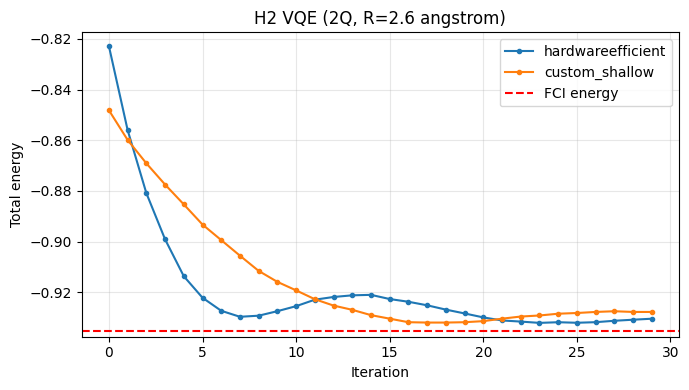

In [5]:
rows = [
    ('hardwareefficient', res_he.energy_history, e_he),
    ('custom_shallow', res_custom.energy_history, e_custom),
]

print('=== H2 2Q comparison ===')
for name, _, e in rows:
    print(name, '| best_total =', round(e, 8), '| abs_err_fci =', round(abs(e - fci_energy), 8))

plt.figure(figsize=(7, 4))
for name, hist, _ in rows:
    plt.plot(np.array(hist) + h2_constant, marker='o', ms=3, label=name)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI energy')
plt.xlabel('Iteration')
plt.ylabel('Total energy')
plt.title(f'H2 VQE (2Q, R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 在真实硬件上运行线路
同时开启zne、rem和cf三种error mitigation

[vqe] prepare run: name=h2_2q_custom num_qubits=2 model=custom layers=1 shots=4096 max_iters=30
Baihua configuration loading done!
The last calibration time was 2026-03-12 12:31:08
[vqe] candidate chips: ['Baihua']
Baihua configuration loading done!
The last calibration time was 2026-03-12 12:31:08
[vqe] running on chip: Baihua
0.9249466709726394 -0.04448179511749612


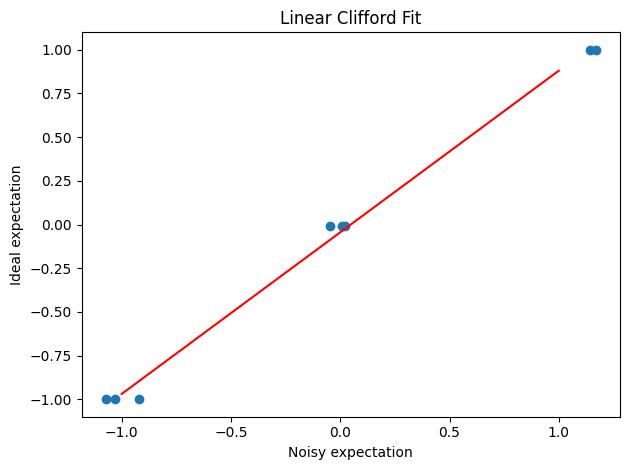

1.0974588423045673 -0.02849353302837947


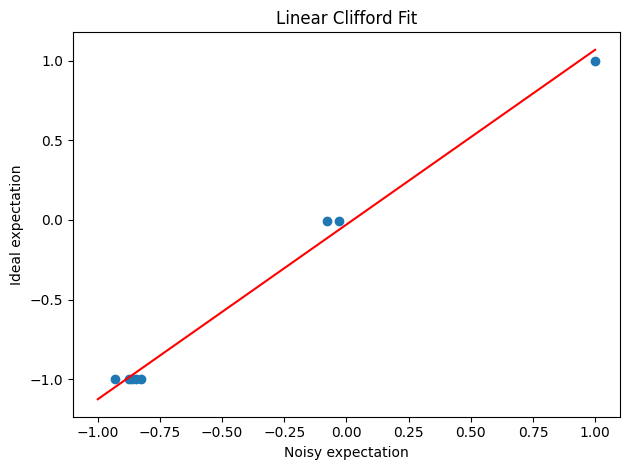

1.0 0.01537719855819571


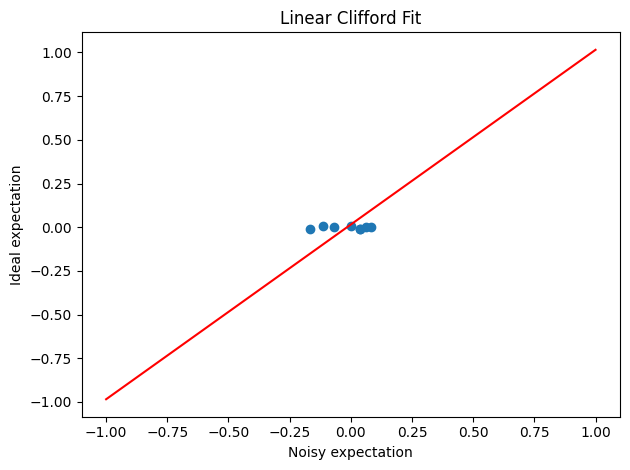

1.0843506380456889 0.019520414418426585


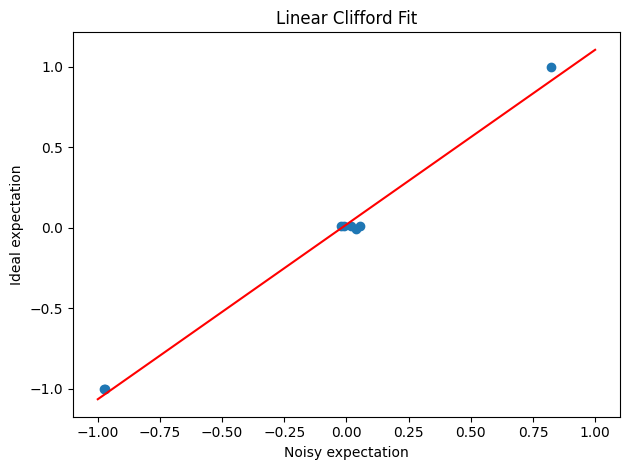

[vqe] clifford fitting prepared: terms=4 samples=8
[vqe] start optimization: iters=30 layers=1 params=1 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=parameter-shift
[vqe] iter 0 start
[vqe] iter 0 energy=-0.222260 grad_norm=0.249953
[vqe] iter 0 new best energy=-0.222260
[vqe] iter 1 start
[vqe] iter 1 energy=-0.241169 grad_norm=0.245090
[vqe] iter 1 new best energy=-0.241169
[vqe] iter 2 start
[vqe] iter 2 energy=-0.255830 grad_norm=0.221623
[vqe] iter 2 new best energy=-0.255830
[vqe] iter 3 start
[vqe] iter 3 energy=-0.274811 grad_norm=0.216723
[vqe] iter 3 new best energy=-0.274811
[vqe] iter 4 start
[vqe] iter 4 energy=-0.266598 grad_norm=0.191108
[vqe] iter 5 start
[vqe] iter 5 energy=-0.262875 grad_norm=0.175152
[vqe] iter 6 start
[vqe] iter 6 energy=-0.289759 grad_norm=0.170717
[vqe] iter 6 new best energy=-0.289759
[vqe] iter 7 start
[vqe] iter 7 energy=-0.277609 grad_norm=0.152485
[vqe] iter 8 start
[vqe] iter 8 energy=-0.288913 grad_norm=0.117201
[vqe] iter 9 s

<Figure size 640x480 with 0 Axes>

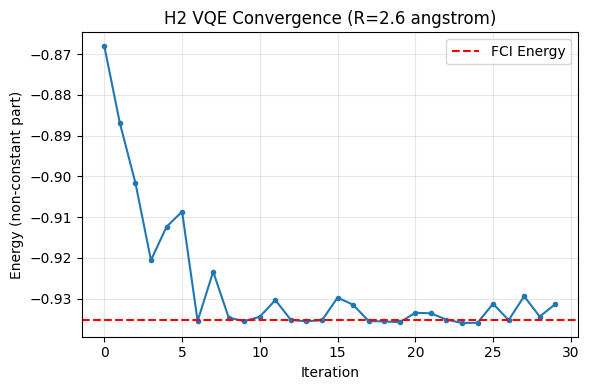

In [8]:
cfg['prefer_chips'] = 'Baihua'
cfg['zne'] = True
cfg['readout_mitigation'] = True
cfg['clifford_fitting'] = True
cfg['clifford_fitting_num_samples'] = 8

runner_cmp = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    zne=cfg['zne'],
    readout_mitigation=cfg['readout_mitigation'],
    shift=cfg['shift'],
    clifford_fitting=cfg['clifford_fitting'],
    clifford_fitting_num_samples=cfg['clifford_fitting_num_samples']
)

kwargs = {
    'name': f'h2_2q_custom',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': h2_2q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': custom_qc,
    'prefer_chips': cfg['prefer_chips'],
}

res = runner_cmp.run_model(**kwargs)
e_total = h2_constant + res.best_energy
abs_error_fci = abs(e_total - fci_energy)

print('=== 2-Qubit H2 VQE Result ===')
print('Estimated total energy:  ', round(e_total, 8))
print('FCI reference energy:    ', round(fci_energy, 8))
print('Absolute error vs FCI:   ', round(abs_error_fci, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(res.energy_history) + h2_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Energy (non-constant part)')
plt.title(f'H2 VQE Convergence (R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()